# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = 'jmontoyo.soler@gmail.com'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/jmontoyo.soler@gmail.com/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

# dataset = ...
# df = ...
# df['species'] = ...
# df.head()

import pandas as pd
from sklearn import datasets

dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df["species"] = [dataset.target_names[i] for i in dataset.target]

print("Dimensiones:", df.shape)
print("Especies:", df["species"].unique())
display(df.head())
display(df.describe())


Dimensiones: (150, 5)
Especies: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
150.0,150.0,150.0,150.0
5.843333333333334,3.0573333333333337,3.7580000000000005,1.1993333333333336
0.828066127977863,0.4358662849366982,1.7652982332594662,0.7622376689603465
4.3,2.0,1.0,0.1
5.1,2.8,1.6,0.3
5.8,3.0,4.35,1.3
6.4,3.3,5.1,1.8
7.9,4.4,6.9,2.5


### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

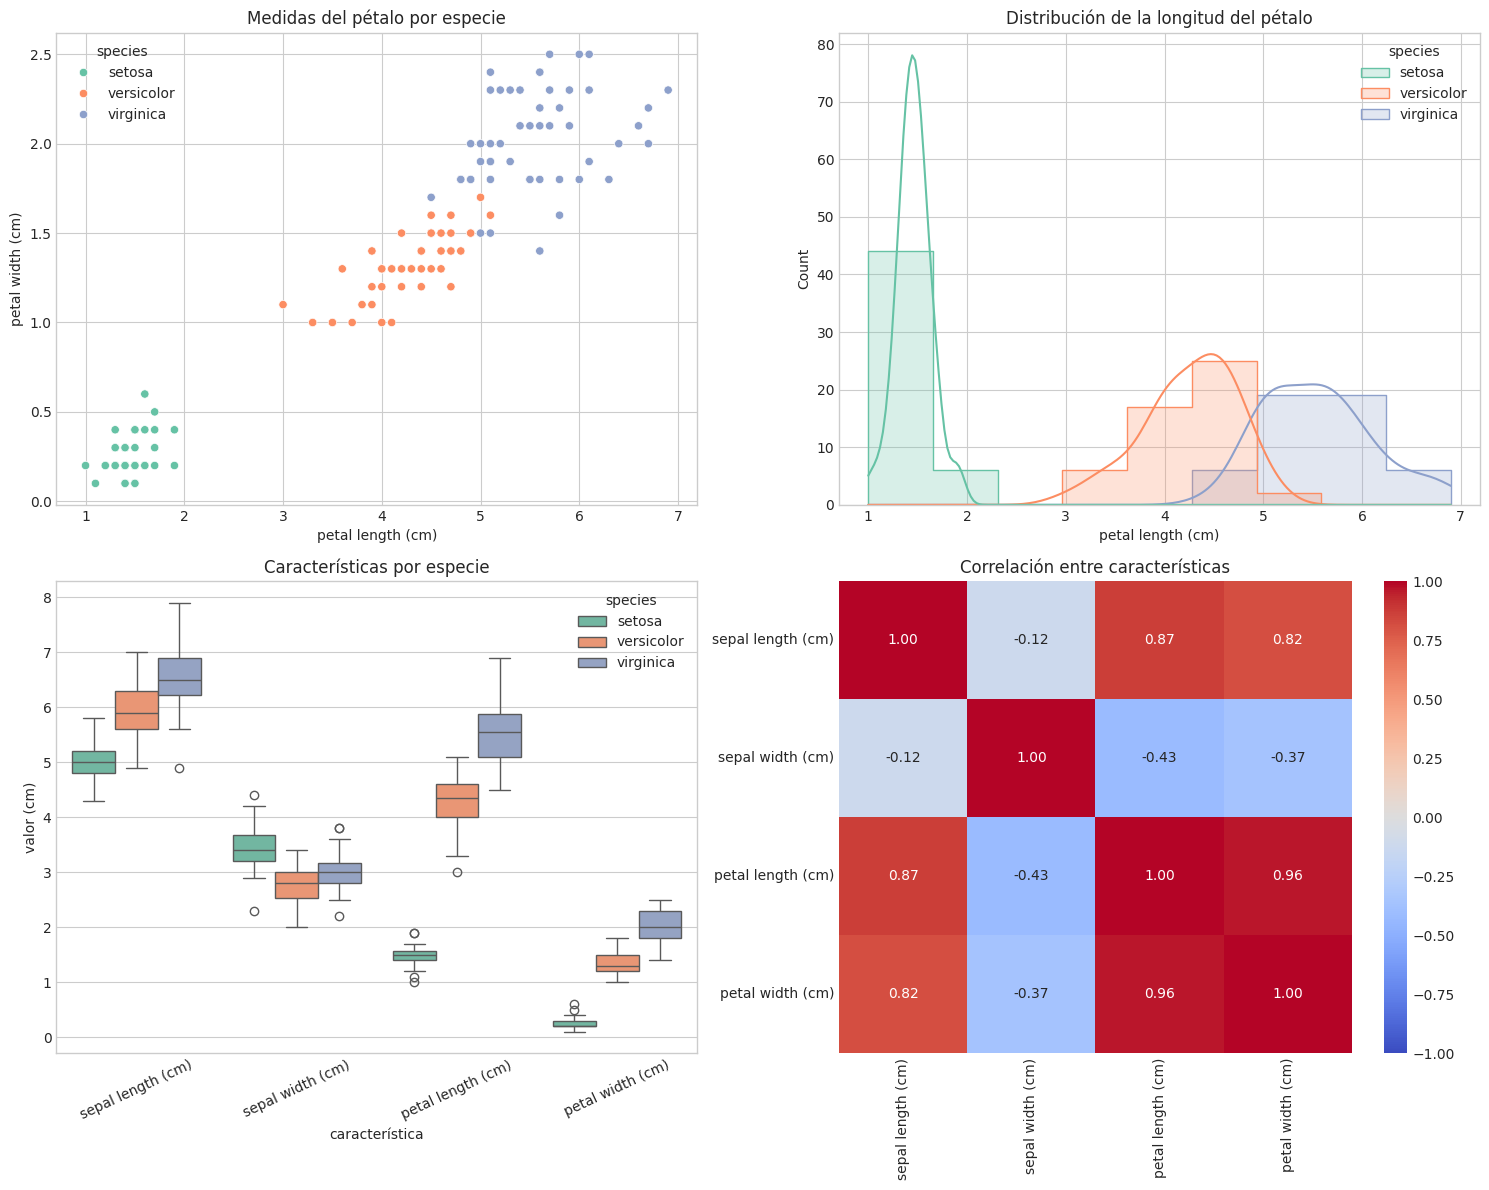

In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación

# fig, axes = plt.subplots(2, 2, figsize=(15, 12))
# ...
# plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.

import matplotlib.pyplot as plt
import seaborn as sns

features = df.select_dtypes(include="number").columns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Relación entre largo y ancho del pétalo
sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)",
    hue="species", ax=axes[0, 0]
)
axes[0, 0].set_title("Medidas del pétalo por especie")

# Distribución de la longitud del pétalo
sns.histplot(
    data=df, x="petal length (cm)", hue="species",
    kde=True, element="step", ax=axes[0, 1]
)
axes[0, 1].set_title("Distribución de la longitud del pétalo")

# Boxplots de las características por especie
df_long = df.melt(
    id_vars="species", value_vars=features,
    var_name="característica", value_name="valor (cm)"
)
sns.boxplot(
    data=df_long, x="característica", y="valor (cm)",
    hue="species", ax=axes[1, 0]
)
axes[1, 0].tick_params(axis="x", rotation=25)
axes[1, 0].set_title("Características por especie")

# Matriz de correlación
sns.heatmap(
    df[features].corr(), annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 1]
)
axes[1, 1].set_title("Correlación entre características")

plt.tight_layout()
plt.show()


setosa se distingue por sus pétalos pequeños. Versicolor y virginica tienen solapamiento, aunque las medidas del pétalo ayudan a separarlas. La longitud y el ancho del pétalo muestran una correlación positiva fuerte.

## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
# X = ...
# y = ...

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases

# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.

from sklearn.model_selection import train_test_split

X = df.drop(columns="species")
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

print("\nClases en entrenamiento:")
print(y_train.value_counts().sort_index())

print("\nClases en prueba:")
print(y_test.value_counts().sort_index())


Entrenamiento: (120, 4) (120,)
Prueba: (30, 4) (30,)

Clases en entrenamiento:
species
setosa        40
versicolor    40
virginica     40
Name: count, dtype: int64

Clases en prueba:
species
setosa        10
versicolor    10
virginica     10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-6141d30725d64619ac342db2de2bd435?o=7474656033369312
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-461c598cf5b741c3856bce257d5aa4b6?o=7474656033369312
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-8f396b4902f04fe4bec56fbd097fe222?o=7474656033369312
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-a26a57168c4a465784c65648e774289a?o=7474656033369312
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-f5ba558317854404948ccd0946a5eeec?o=7474656033369312
🔗 View Logged Model at: https://dbc-8c51fcb2-8682.cloud.databricks.com/ml/experiments/2825716077149661/models/m-4053c0c1c4424110b16143cc70ac8f25?o=7474656033369312


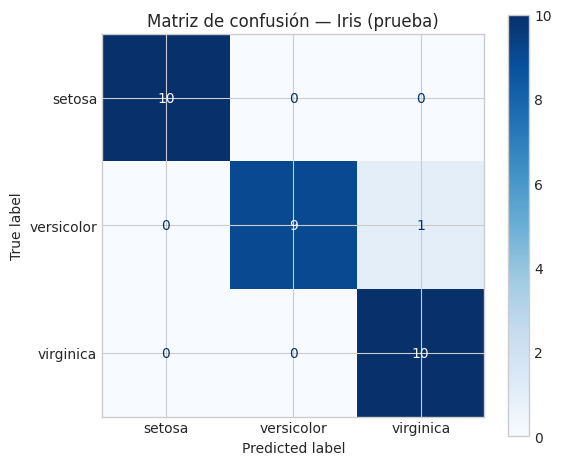

Accuracy entrenamiento: 0.983
Accuracy prueba:        0.967
Precision macro:        0.970
Recall macro:           0.967
F1 macro:               0.967
F1 macro CV:            0.958 ± 0.027
Run ID de MLflow:       b56f1d3359864c138862b51f41fd5c60


In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.
# mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
# with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
#     TODO: Define hiperparámetros del árbol.
#     max_depth = ...
#     max_features = ...
#     random_state = ...
#
#     TODO: Crea y entrena DecisionTreeClassifier.
#     dt = DecisionTreeClassifier(...)
#     dt.fit(...)
#
#     TODO: Genera predicciones para train y test.
#     y_pred_train = ...
#     y_pred_test = ...
#
#     TODO: Calcula métricas de clasificación.
#     accuracy_test = ...
#     precision_test = ...
#     recall_test = ...
#     f1_test = ...
#
#     TODO: Evalúa con cross-validation.
#     cv_scores = ...
#
#     TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
#
#     TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
#
#     TODO: Escribe una breve interpretación de los resultados.

import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

# MLflow registra automáticamente el modelo y sus hiperparámetros.
# Registraremos las métricas de evaluación con nombres claros.
mlflow.sklearn.autolog(log_post_training_metrics=False)

with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
    max_depth = 3
    max_features = None
    random_state = 42

    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        max_features=max_features,
        random_state=random_state
    )
    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(
        y_test, y_pred_test, average="macro", zero_division=0
    )
    recall_test = recall_score(
        y_test, y_pred_test, average="macro", zero_division=0
    )
    f1_test = f1_score(
        y_test, y_pred_test, average="macro", zero_division=0
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        dt, X_train, y_train, cv=cv, scoring="f1_macro"
    )

    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_metrics({
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "precision_macro_test": precision_test,
        "recall_macro_test": recall_test,
        "f1_macro_test": f1_test,
        "cv_f1_macro_mean": cv_scores.mean(),
        "cv_f1_macro_std": cv_scores.std()
    })

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_test,
        labels=dt.classes_,
        cmap="Blues",
        ax=ax
    )
    ax.set_title("Matriz de confusión — Iris (prueba)")
    plt.tight_layout()
    mlflow.log_figure(fig, "matriz_confusion.png")
    plt.show()

    print(f"Accuracy entrenamiento: {accuracy_train:.3f}")
    print(f"Accuracy prueba:        {accuracy_test:.3f}")
    print(f"Precision macro:        {precision_test:.3f}")
    print(f"Recall macro:           {recall_test:.3f}")
    print(f"F1 macro:               {f1_test:.3f}")
    print(f"F1 macro CV:            {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"Run ID de MLflow:       {run.info.run_id}")

## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**
- ¿Qué ventajas tiene un árbol de decisión?
un árbol de decisión es bastante fácil de entender porque va haciendo preguntas sobre los datos hasta llegar a una respuesta. Por ejemplo, puede fijarse en el tamaño de un pétalo para decidir la especie.

- ¿Qué riesgos tiene respecto a overfitting?
si dejamos que el árbol crezca mucho, puede aprenderse demasiado bien los ejemplos de entrenamiento y despues con flores nuevas, podría equivocarse más.
- ¿Cómo interpretarías una matriz de confusión multiclase?
sirve para ver cuántas flores ha clasificado bien y en cuáles se ha equivocado, los números de la diagonal son los aciertos y los que están fuera muestran qué especies ha confundido.

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.

# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
# configuraciones = [...]
# for config in configuraciones:
#     # Entrena, evalúa y registra cada configuración en MLflow
#     pass

# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# param_grid = {...}
# grid_search = GridSearchCV(...)
# grid_search.fit(...)

# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
# modelos = {...}
# resultados = []
# for nombre, modelo in modelos.items():
#     # Entrena y compara métricas
#     pass

# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
# incorrect_indices = ...
# TODO: inspecciona las muestras mal clasificadas.

# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_pca = ...
